***** RED NEURONAL MODELO BASE VS MODELO CON REGULARIZACIÓN **** 

DATASET
Datos de entrenamiento: (350, 2)
Datos de prueba: (150, 2)
Funcion de activación: ReLu
Optimizador: Gradiente SGD
Regulizadores a prueba: L2, Dropout, Early Stopping

Entrenando modelos...
[Early Stopping] Early Stopping activado en la época 2845



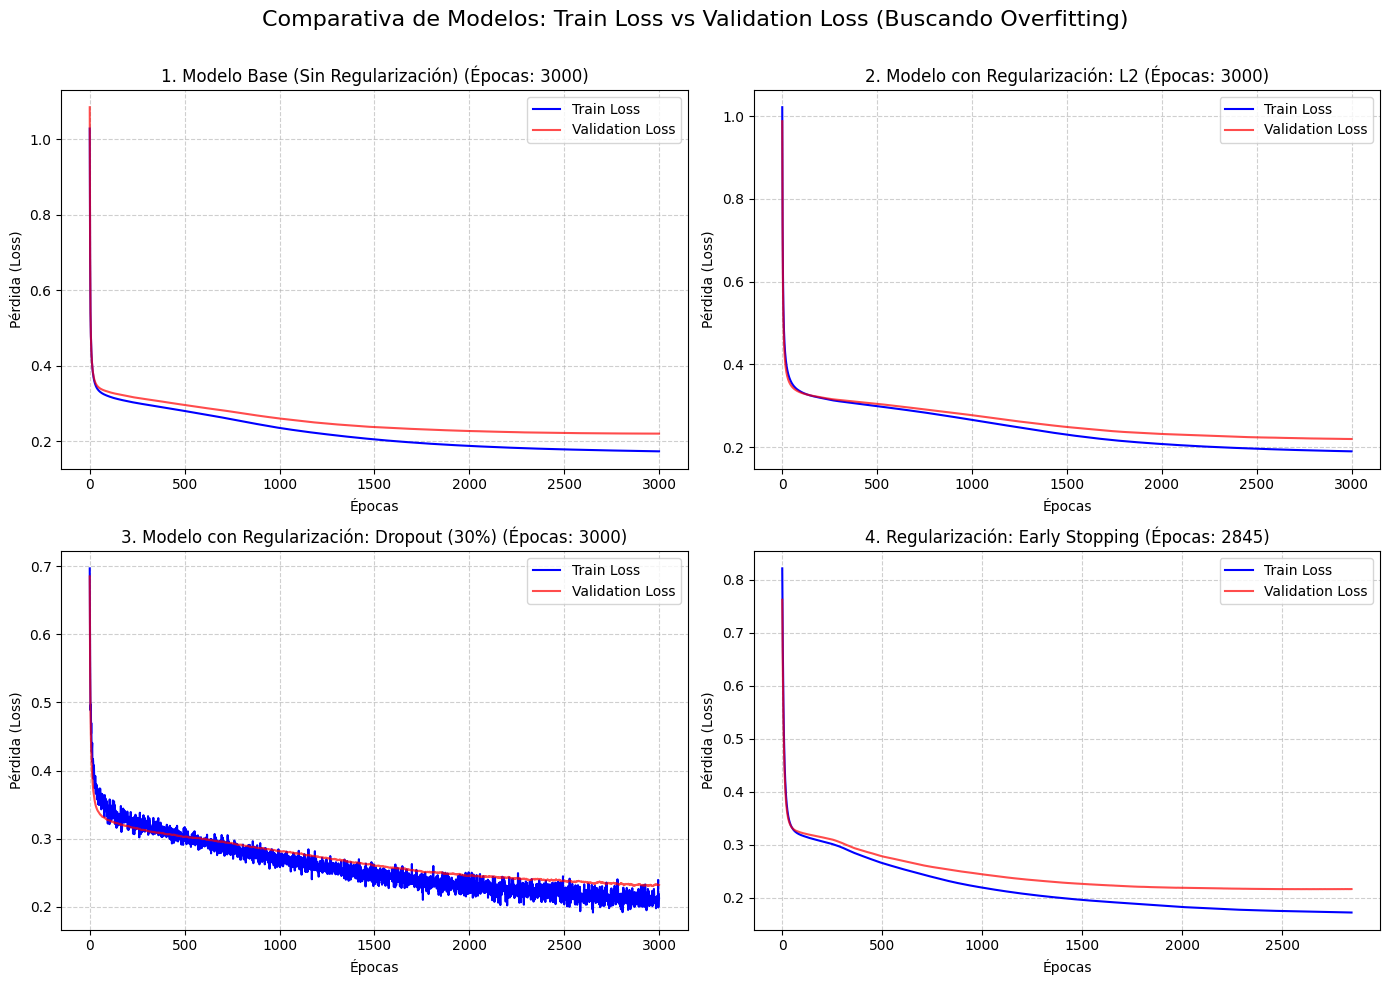

In [1]:
# Importacion de librerias necesarias
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

print("***** RED NEURONAL MODELO BASE VS MODELO CON REGULARIZACIÓN **** \n")

# Creacion del Dataset de datos
np.random.seed(42)
datos_entrada, etiquetas = make_moons(n_samples=500, noise=0.3)  #500 datos iniciales
etiquetas = etiquetas.reshape(-1,1) #Si es dato de entrenamiento o prueba

datos_entrenamiento, datos_prueba, etiquetas_entrenamiento, etiquetas_prueba = train_test_split(
    datos_entrada, etiquetas, test_size=0.3, random_state=42
)

print("DATASET")
print("Datos de entrenamiento:", datos_entrenamiento.shape) #Resultado total cantidad datos para entrenamiento
print("Datos de prueba:", datos_prueba.shape) #Resultado total cantidad datos para pruebas
print("Funcion de activación: ReLu")
print("Optimizador: Gradiente SGD")
print("Regulizadores a prueba: L2, Dropout, Early Stopping")
print("\nEntrenando modelos...")

# Funciones de activacion (ReLU)
def sigmoid(x):
    return 1/(1+np.exp(-np.clip(x, -500, 500))) # Clip para evitar warnings de overflow

def relu(x):
    return np.maximum(0,x)

def derivada_relu(x):
    return (x>0).astype(float)


# Funcion Inicializar parametros
def inicializar_parametros():
    neuronas_ocultas = 50  # 50 neuronas ocultas para propiciar overfitting

    pesos_capa_oculta = np.random.randn(2, neuronas_ocultas) * 0.5  #Genera 2 entradas con 50 pesos aletorios para cada capa oculta por entrada
    sesgos_capa_oculta = np.zeros((1, neuronas_ocultas))

    pesos_capa_salida = np.random.randn(neuronas_ocultas, 1) * 0.5 #Genera 50 pesos aletorios para cada capa oculta por salida
    sesgos_capa_salida = np.zeros((1,1))

    return pesos_capa_oculta, sesgos_capa_oculta, pesos_capa_salida, sesgos_capa_salida


# Funcion Feedforward (Propagacion hacia adelante)
def propagacion_adelante(datos_entrada, W1, b1, W2, b2, dropout_rate=0.0, entrenando=True):

    Z1 = datos_entrada.dot(W1) + b1 #Calculo de capas ocultas (x1*w1 + x2*w2) + sesgo

    #Aplicamos la funcion de activacion al calculo de la capa oculta de entrada
    A1 = relu(Z1)

    mascara_dropout = None
    # Aplicar Dropout solo durante el entrenamiento
    if entrenando and dropout_rate > 0.0:
        keep_prob = 1.0 - dropout_rate
        # Inverted Dropout: Apagamos neuronas y escalamos las activas
        mascara_dropout = (np.random.rand(*A1.shape) < keep_prob).astype(float) / keep_prob
        A1 = A1 * mascara_dropout

    Z2 = A1.dot(W2) + b2 #Calculo de capas de salida (h1*w1 + h2*w2 + h3*w3 + h4*w4 .... h50*w50)
    A2 = sigmoid(Z2) #ŷ = sigmoid(suma_capa_salida) Prediccion

    return Z1, A1, Z2, A2, mascara_dropout


# Funcion Calculo de perdida - Loss (realidad vs predicción)
def calcular_perdida(etiquetas_reales, salida_predicha, W1, W2, lambda_L2):

    m = etiquetas_reales.shape[0]

    perdida = -(1/m)*np.sum(
        etiquetas_reales*np.log(salida_predicha+1e-8) +
        (1-etiquetas_reales)*np.log(1-salida_predicha+1e-8)
    ) #Obtener porcentaje de perdida

    # Modelo de Regularización L2
    regularizacion = (lambda_L2/(2*m)) * (
        np.sum(np.square(W1)) +
        np.sum(np.square(W2))
        )

    return perdida + regularizacion

# Funcion Backpropagation (Propagación del error hacia atrás)
def retropropagacion(X, Y, Z1, A1, A2, W1, W2, lambda_L2, mascara_dropout=None):

    m = X.shape[0]

    dZ2 = A2 - Y  #error = predicción - valor_real

    #Cada peso recibe un gradiente que indica cuánto debe cambiar
    dW2 = (1/m)*A1.T.dot(dZ2) + (lambda_L2/m)*W2
    db2 = (1/m)*np.sum(dZ2, axis=0, keepdims=True)
    dA1 = dZ2.dot(W2.T)

    # Si se usó dropout, la derivada también debe verse afectada por la misma máscara
    if mascara_dropout is not None:
        dA1 = dA1 * mascara_dropout

    #Aplicar funcion de activación
    dZ1 = dA1 * derivada_relu(Z1)

    dW1 = (1/m)*X.T.dot(dZ1) + (lambda_L2/m)*W1
    db1 = (1/m)*np.sum(dZ1, axis=0, keepdims=True)

    return dW1, db1, dW2, db2

# Funcion de Entrenamiento de Red Neuronal con 3000 epocas por defecto
def entrenar_red(X_train, Y_train, X_val, Y_val, config_nombre,
                 lambda_L2=0.0, dropout_rate=0.0, usar_early_stopping=False,
                 epocas=2000, tasa_aprendizaje=0.1):

    #Obtenemos parametros de entrada (inicializar pesos y sesgo)
    W1, b1, W2, b2 = inicializar_parametros()
    historial_perdida_train = []
    historial_perdida_val = []

    mejor_perdida_val = float('inf')
    paciencia = 200 # Cuántas épocas esperar sin mejora
    epocas_sin_mejora = 0
    epoca_final = epocas

    #Iteramos epoca por epoca (3000 en total)
    for epoca in range(epocas):

        #Forward Pass - Propagación hacia adelante para calculan las salidas de la red neuronal
        Z1, A1, Z2, A2_train, mascara = propagacion_adelante(X_train, W1, b1, W2, b2, dropout_rate, entrenando=True)

        #Cálculo de la pérdida (Loss)
        perdida_train = calcular_perdida(Y_train, A2_train, W1, W2, lambda_L2)

        #Forward Pass - Propagación hacia adelante para calculan las salidas de la red neuronal (Sin Dropout, entrenando=False)
        _, _, _, A2_val, _ = propagacion_adelante(X_val, W1, b1, W2, b2, dropout_rate=0.0, entrenando=False)

        #Cálculo de la pérdida (Loss sin penalización L2 real)
        perdida_val = calcular_perdida(Y_val, A2_val, W1, W2, lambda_L2=0.0)

        historial_perdida_train.append(perdida_train)
        historial_perdida_val.append(perdida_val)

        # Backpropagation - Retropropagación del error para ajustar los pesos de la red neuronal y minimizar el error de predicción
        dW1, db1, dW2, db2 = retropropagacion(X_train, Y_train, Z1, A1, A2_train, W1, W2, lambda_L2, mascara)

        # ===== Aplicar tecnicas de Optimizadores Gradiante SGD básico =====
        W1 -= tasa_aprendizaje * dW1 #Ajuste de los pesos (nuevo_peso = peso_actual − learning_rate × gradiente)
        b1 -= tasa_aprendizaje * db1
        W2 -= tasa_aprendizaje * dW2
        b2 -= tasa_aprendizaje * db2
        # ===== Fin de Aplicar tecnicas de Optimizadores =====


        # Early Stopping Logic
        if usar_early_stopping:
            if perdida_val < mejor_perdida_val:
                mejor_perdida_val = perdida_val
                epocas_sin_mejora = 0
            else:
                epocas_sin_mejora += 1
                if epocas_sin_mejora >= paciencia:
                    epoca_final = epoca
                    print(f"[{config_nombre}] Early Stopping activado en la época {epoca}\n")
                    break

    return historial_perdida_train, historial_perdida_val, epoca_final


# ================= EJECUCIÓN DE MODELOS Y COMPARACIÓN =================

epocas_totales = 3000

# Primer aprendizaje: Modelo Base
train_base, val_base, e_base = entrenar_red(
    datos_entrenamiento, etiquetas_entrenamiento, datos_prueba, etiquetas_prueba,
    "Base", lambda_L2=0.0, dropout_rate=0.0, epocas=epocas_totales
) #Entrenamos la red indicando modelo de regularización, valor de regularización y cantidad de epocas

# Segundo aprendizaje: Modelo con Regularización L2
train_l2, val_l2, e_l2 = entrenar_red(
    datos_entrenamiento, etiquetas_entrenamiento, datos_prueba, etiquetas_prueba,
    "L2", lambda_L2=0.1, dropout_rate=0.0, epocas=epocas_totales
)

# Tercer aprendizaje: Modelo con Dropout (Tasa de 30% de apagado)
train_drop, val_drop, e_drop = entrenar_red(
    datos_entrenamiento, etiquetas_entrenamiento, datos_prueba, etiquetas_prueba,
    "Dropout", lambda_L2=0.0, dropout_rate=0.3, epocas=epocas_totales
)

# Cuarto aprendizaje: Modelo con Early Stopping
train_es, val_es, e_es = entrenar_red(
    datos_entrenamiento, etiquetas_entrenamiento, datos_prueba, etiquetas_prueba,
    "Early Stopping", lambda_L2=0.0, dropout_rate=0.0, usar_early_stopping=True, epocas=epocas_totales
)

#Graficamos la comparativa entre funciones de activacion y su evolucion de perdida
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Comparativa de Modelos: Train Loss vs Validation Loss (Buscando Overfitting)", fontsize=16)

def plot_metric(ax, train_loss, val_loss, title, final_epoch):
    ax.plot(train_loss, label='Train Loss', color='blue')
    ax.plot(val_loss, label='Validation Loss', color='red', alpha=0.7)
    ax.set_title(f"{title} (Épocas: {final_epoch})")
    ax.set_xlabel("Épocas")
    ax.set_ylabel("Pérdida (Loss)")
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.6)

plot_metric(axs[0, 0], train_base, val_base, "1. Modelo Base (Sin Regularización)", e_base)
plot_metric(axs[0, 1], train_l2, val_l2, "2. Modelo con Regularización: L2", e_l2)
plot_metric(axs[1, 0], train_drop, val_drop, "3. Modelo con Regularización: Dropout (30%)", e_drop)
plot_metric(axs[1, 1], train_es, val_es, "4. Regularización: Early Stopping", e_es)

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

# **Red Neuronal Modelo Base vs Modelos con Regularización**

Para este algoritmo se agregaron dos entradas X1, X2, cincuenta capas ocultas H1, H2, H3, H4 ... H50 y una salida. Los datos de entrada y etiquetas se generan una unica vez desde un dataset de numpy.
Este modelo emplea la funcion de activación ReLu, el optimizador Gradiante SGD y los mismos datos de entrada para cada regularización para asi poder realizar una comparacion valida. Para la comparación de entrenamiento de modelos con regularización se eligio L2, Dropout y Early Stopping.

**Esquema para L2:**
Dataset ──► Forward Pass ──► Predicción ──► Cálculo de error (regularización L2) ──► Backpropagation (regularización L2 en gradiantes) ──► Ajuste de pesos con Optimizadores (SGD) ──► Repetir 3000 veces ──► Modelo entrenado

**Esquema para Dropout:**
Dataset ──► Forward Pass (regularización Dropout al 30%) ──► Predicción ──► Cálculo de error ──► Backpropagation (mascara Dropout) ──► Ajuste de pesos con Optimizadores (SGD) ──► Repetir 3000 veces ──► Modelo entrenado

**Esquema para Early Stopping:**
Dataset ──► Forward Pass ──► Predicción ──► Cálculo de error ──► Backpropagation ──► Ajuste de pesos con Optimizadores (SGD) ──► Validar cada 200 epocas si no hay mejoria de perdida (regularización Early Stopping) ──►  Repetir hasta que el entrenamiento mejore ──► Modelo entrenado


De acuerdo a esto y realizando un analisis de comparación se puede concluir que:
- El **modelo base** genera un buen proceso de entrenamiento gracias al optimizador que hace todo lo posible por llevar el error de entreno a cero, pero permite que los pesos de las capas ocultas crezcan libremente corrompiendo la salida final basándose en reglas muy frágiles, asumiendo que el futuro será exactamente igual al pasado memorizado.
- El **uso de regularización L2** reduce el overfitting y hace el entrenamiento más estable, limitando el crecimiento de los pesos y mejorando la capacidad de generalización del modelo. Es ideal cuando se desea todas las variables de entrada aportean un poco de información sin descartar nada. El parámetro λ en la regularización L2 controla la intensidad de la penalización sobre los pesos del modelo. En este codigo se probaron diferentes valores (por ejemplo 0.1, 0.001 y 1) concluyendo que valores excesivos pueden provocar underfitting.
- El **uso de regularización Dropout** permite el "apagado" o "silenciado temporal" del 30% de las capas ocultas en cada iteración de entrenamiento.Esto evita la co-adaptación de neuronas compañeras para arreglar sus errores, forzando a que cada una aprenda por sí misma de manera independiente. En pocas palabras, el modelo es mas redundante y resistente a la pérdida de información.
- El **uso de regularización Early Stopping** no toca los pesos ni apaga neuronas. Permite el proceso de aprendizaje fluya pero observando, cuando se detecta el Overfitting está a punto de comenzar se detiene el proceso de entreno. Esto evita el sesgo comience a convertirse en varianza y que se restaure los pesos de la mejor época pasada. Su mayor ventaja, además de evitar el sobreajuste, es el enorme ahorro de tiempo y recursos computacionales.


***Nota:** Para ajustar a gusto el valor de λ en el codigo verifique la variable "lambda_L2". Y para ajustar el valor de apagado verifique la variable "dropout_rate".*
